In [40]:
from pydantic import BaseModel,Field
from dotenv import load_dotenv
load_dotenv()
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph,START,END
from langchain.chat_models import init_chat_model
from typing import Literal
from langchain.agents import create_agent
from langchain_tavily import TavilySearch
from langchain.tools import tool

In [41]:
class flowState(BaseModel):
    question:str=Field(description="User Asked Questions")
    category:Literal['coding','google_search','weather']=Field(default="google_search")
    answer:str=Field(default="")

In [42]:
class QuestionCategory(BaseModel):
    category:Literal['coding','google_search','weather']=Field(default="google_search",description="User Asked Questions")

In [43]:
llm=init_chat_model(
    model="mistral-small-latest"
)

In [44]:
search=TavilySearch()
import requests
google_agent=create_agent(
    model="mistral-small-latest",
    tools=[search],
    system_prompt="You are search agent and can search the user query on google "
)


@tool
def get_weather(city: str) -> str:
    """Get the current weather of a city."""
    url = f"https://wttr.in/{city}?format=%c+%t"

    try:
        response = requests.get(url, timeout=10)

        if response.status_code == 200:
            return response.text.strip()

        return f"Weather API returned status code {response.status_code}"

    except requests.RequestException as e:
        return f"Weather API error: {str(e)}"

weather_agent=create_agent(
    model="mistral-small-latest",
    tools=[get_weather],
    system_prompt="You are an AI with expertise in weather forecasting and predictions"
)

In [45]:
def check_question(state:flowState)->flowState:
    st_llm=llm.with_structured_output(QuestionCategory)
    res=st_llm.invoke(f"I want to know the category of my question is:{state.question}.if you are not sure then just give 'google_search' as category")
    state.category=res.category
    return state

In [46]:
flow=flowState(question="Who is the weather of india?")
check_question(flow)

flowState(question='Who is the weather of india?', category='weather', answer='')

In [47]:
def route(state:flowState)->Literal['coding','google_search','weather']:
    return state.category

In [48]:
def coding_node(state:flowState)->flowState:
    print('Coding_Node................')
    res=llm.invoke(f"You are a coding expert: {state.question}")
    state.answer=res.content
    return state

def google_node(state:flowState)->flowState :
    res=google_agent.invoke({'messages':[{'role':'user','content':state.question}]})
    state.answer=res['messages'][-1].content
    return state

def weather_node(state:flowState)->flowState:
    res=weather_agent.invoke({'messages':[{'role':'user','content':state.question}]})
    state.answer=res['messages'][-1].content
   
    return state

In [49]:
graph=StateGraph(flowState)

graph.add_node('check_question',check_question)
graph.add_node('coding',coding_node)
graph.add_node('google_search',google_node)
graph.add_node('weather',weather_node)



In [50]:
graph.add_edge(START,"check_question")
graph.add_conditional_edges('check_question',route)
graph.add_edge('coding',END)
graph.add_edge('weather',END)
graph.add_edge('google_search',END)
graph=graph.compile()

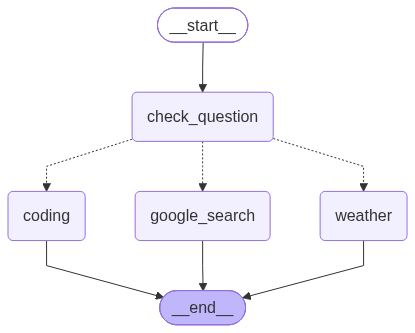

In [51]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [53]:
respoonse=graph.invoke({'question':"What is the temperature of kathmandu?"
""})
print(respoonse.keys())
print(respoonse['answer'])

dict_keys(['question', 'category', 'answer'])
The current temperature in **Kathmandu** is **20°C** (68°F).
